In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## RESNET-50 İLK KOD


Sınıflar: ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/3] | Train Acc: 73.94% | Val Acc: 91.97% | Train Loss: 0.7990 | Val Loss: 0.2451 | Time: 4454.5s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/3] | Train Acc: 91.13% | Val Acc: 94.64% | Train Loss: 0.2728 | Val Loss: 0.1643 | Time: 295.2s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [3/3] | Train Acc: 94.29% | Val Acc: 95.68% | Train Loss: 0.1745 | Val Loss: 0.1367 | Time: 291.8s
Model kaydedildi: resnet50_trained.pth


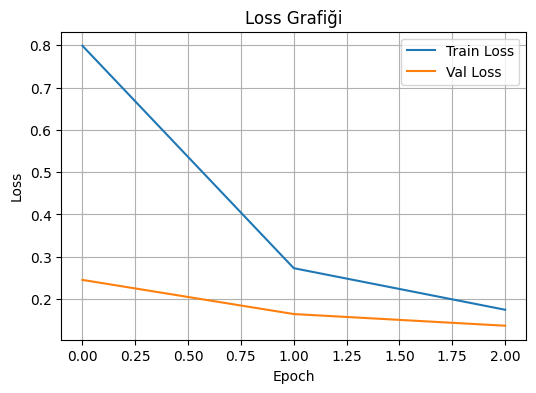

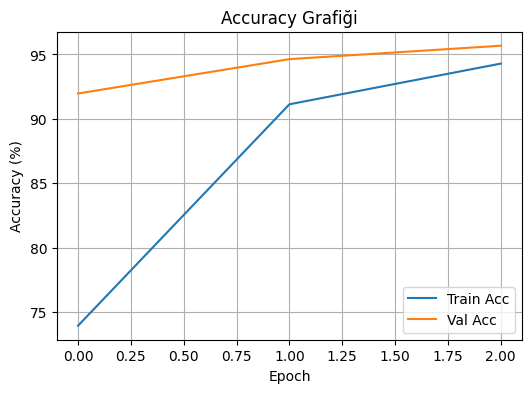

In [ ]:

# RESNET-50


import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import timm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import os



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("/content/drive/MyDrive/Derin_Ogrenme/best.ptler", exist_ok=True)



train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.2),

    transforms.RandomApply(
        [transforms.RandomRotation(degrees=10)],
        p=0.15
    ),

    transforms.RandomApply(
        [transforms.ColorJitter(brightness=0.15)],
        p=0.10
    ),

    transforms.RandomApply(
        [transforms.ColorJitter(contrast=0.15)],
        p=0.10
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


data_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2"

train_dataset = datasets.ImageFolder(data_dir + "/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(data_dir + "/val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(data_dir + "/test",  transform=val_test_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Sınıflar:", class_names)

#----------------------------------------------------------------------------
model = timm.create_model("resnet50", pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # her br parametreyi ağırlık + bias güncelleyen algoritma

num_epochs = 5

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}



for epoch in range(num_epochs):
    start = time.time()

    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss /= len(train_loader)



    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    val_loss /= len(val_loader)

    end = time.time()


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)


    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Time: {end-start:.1f}s")



torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Derin_Ogrenme/best.ptler/best.pt"
)
print("Model Drive'a kaydedildi: /content/drive/MyDrive/Derin_Ogrenme/best.ptler/best.pt")

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.legend()
plt.show()



## RESNET-50 ÇIKTILAR (İLK KOD)

In [ ]:
import torch
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------------
# MODELİ YÜKLE
# -------------------------------
model = timm.create_model("resnet50", pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

# MODEL DOSYANIN TAM YOLU:
model_path = "/content/resnet50_trained.pth"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# -------------------------------
# TEST SET ÜZERİNDE TAHMİN YAP
# -------------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# -------------------------------
# CONFUSION MATRIX OLUŞTUR
# -------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix (resnet50_trained.pth)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# RAPOR
# -------------------------------
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(




# **En iyi loss**

Using device: cuda
Class sayısı: 6

--- CE Loss ---


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


CrossEntropy | Epoch 1 Loss: 0.5264


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


CrossEntropy | Epoch 2 Loss: 0.1604


...

FocalLoss | Epoch 1 Loss: 0.1455


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


FocalLoss | Epoch 2 Loss: 0.0072


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


FocalLoss | Epoch 3 Loss: 0.0039


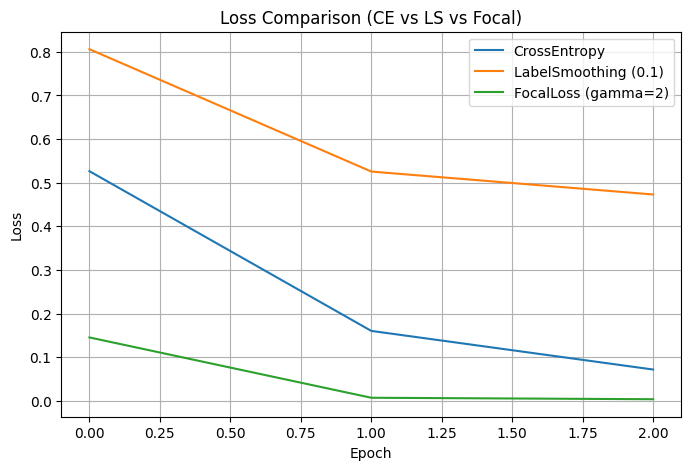

In [ ]:
##loss karşılaştırma

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

# ---------------------------
# 0) DEVICE AYARI
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# 1) TRANSFORMLAR
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ---------------------------
# 2) DATASET YOLU (Colab uyumlu)
# ---------------------------

data_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2/train"

dataset = datasets.ImageFolder(data_dir, transform=transform)

# Sadece ilk 5000 görüntüyü alıyoruz
subset_size = 5000
indices = list(range(len(dataset)))
random.shuffle(indices)              
subset_indices = indices[:subset_size]

subset = Subset(dataset, subset_indices)
loader = DataLoader(subset, batch_size=32, shuffle=True, num_workers=2)
num_classes = len(dataset.classes)
print("Class sayısı:", num_classes)

# ---------------------------
# 3) MODEL ALMA FONKSİYONU
# ---------------------------
def get_model():
    model = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model.to(device)

# ---------------------------
# 4) FOCAL LOSS TANIMI
# ---------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2): # zor örneklere ne kadar ağırlık verecek
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, labels):
        ce_loss = self.ce(logits, labels)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

# ---------------------------
# 5) MINI TRAIN FONKSİYONU
# ---------------------------
def mini_train(model, criterion, name):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    losses = []

    for epoch in range(3):  # 3 epoch → hızlı test
        total_loss = 0
        model.train()

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)

        print(f"{name} | Epoch {epoch+1} Loss: {avg_loss:.4f}")

    return losses

# ---------------------------
# 6) LOSS KARŞILAŞTIRMASI BAŞLAT
# ---------------------------
print("\n--- CE Loss ---")
loss_ce = mini_train(get_model(), nn.CrossEntropyLoss(), "CrossEntropy")

print("\n--- Label Smoothing Loss ---")
loss_ls = mini_train(get_model(), nn.CrossEntropyLoss(label_smoothing=0.1), "LabelSmoothing")

print("\n--- Focal Loss ---")
loss_focal = mini_train(get_model(), FocalLoss(gamma=2), "FocalLoss")

# ---------------------------
# 7) GRAFİK ÇİZ
# ---------------------------
plt.figure(figsize=(8,5))
plt.plot(loss_ce, label="CrossEntropy")
plt.plot(loss_ls, label="LabelSmoothing (0.1)")
plt.plot(loss_focal, label="FocalLoss (gamma=2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison (CE vs LS vs Focal)")
plt.legend()
plt.grid()
plt.show()

# **En iyi Optimizasyon**

In [ ]:
# Optimizasyon alg.
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import pandas as pd
from tqdm import tqdm
import random
import numpy as np
from IPython.display import display

# ---------------------------------------------------------
# 2) SEED (ADİL KIYAS İÇİN)
# ---------------------------------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ---------------------------------------------------------
# 3) FOCAL LOSS (MULTI-CLASS)
# ---------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# ---------------------------------------------------------
# 4) DATASET & TRANSFORM
# ---------------------------------------------------------
data_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2/train"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Toplam veri sayısı:", len(full_dataset))
print("Sınıf sayısı:", len(full_dataset.classes))
print("Sınıflar:", full_dataset.classes)

# ---------------------------------------------------------
# 5) İLK 5.000 VERİ
# ---------------------------------------------------------
subset_size = 5000
indices = list(range(len(full_dataset)))
random.shuffle(indices)
subset_indices = indices[:subset_size]

subset_dataset = Subset(full_dataset, subset_indices)

train_loader = DataLoader(
    subset_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# ---------------------------------------------------------
# 6) MODEL
# ---------------------------------------------------------
def get_model(num_classes):
    model = models.densenet201(pretrained=True)
    model.classifier = nn.Linear(
        model.classifier.in_features,
        num_classes
    )
    return model

# ---------------------------------------------------------
# 7) OPTIMIZER SEÇİCİ
# ---------------------------------------------------------
def get_optimizer(name, model):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=1e-4)

    if name == "AdamW":
        return optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    if name == "SGD":
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

    if name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=1e-4)

    if name == "NAdam":
        return optim.NAdam(model.parameters(), lr=1e-4)

# ---------------------------------------------------------
# 8) EĞİTİM FONKSİYONU
# ---------------------------------------------------------
def train_model(model, optimizer, criterion, loader, device, epochs=3):
    model.to(device)
    model.train()

    epoch_losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in tqdm(loader, desc=f"Epoch {epoch+1}"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        epoch_losses.append(avg_loss)

    return epoch_losses

# ---------------------------------------------------------
# 9) OPTIMIZER KARŞILAŞTIRMA
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes)
criterion = FocalLoss(alpha=1.0, gamma=2.0)

optimizer_names = ["Adam", "AdamW", "SGD", "RMSprop", "NAdam"]
results = {}

for opt_name in optimizer_names:
    print(f"\nOptimizer: {opt_name}")

    model = get_model(num_classes)
    optimizer = get_optimizer(opt_name, model)

    losses = train_model(
        model,
        optimizer,
        criterion,
        train_loader,
        device,
        epochs=3
    )

    results[opt_name] = losses


df_results = pd.DataFrame(results)
df_results.index = [f"Epoch {i+1}" for i in range(len(df_results))]
print("\n LOSS KARŞILAŞTIRMA TABLOSU")
display(df_results)


final_losses = df_results.iloc[-1]  # son epoch lossları
best_optimizer = final_losses.idxmin()
best_loss = final_losses.min()

print("\n EN İYİ OPTIMIZER SONUCU")
print(f"Seçilen Optimizer : {best_optimizer}")
print(f"Son Epoch Loss    : {best_loss:.4f}")

Toplam veri sayısı: 18484
Sınıf sayısı: 6
Sınıflar: ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']

Optimizer: Adam


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1:   6%|▌         | 9/157 [00:26<06:57,  2.82s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1:  44%|████▍     | 69/157 [00:58<00:45,  1.96it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette im


Optimizer: AdamW


Epoch 1:  42%|████▏     | 66/157 [00:37<00:47,  1.90it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1:  94%|█████████▎| 147/157 [01:20<00:05,  1.96it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2:  21%|██        | 33/157 [00:18<01:04,  1.92it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2:  60%|█████▉    | 94/157 [00:51<00:33,  1.86it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3:   8%|▊         | 12/157 [00:06<01:14,  1.95it/s]/usr/local


Optimizer: SGD


...


Optimizer: NAdam


Epoch 1:  15%|█▍        | 23/157 [00:12<01:10,  1.91it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1:  66%|██████▌   | 104/157 [00:57<00:27,  1.95it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2:  56%|█████▌    | 88/157 [00:49<00:39,  1.76it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2:  62%|██████▏   | 98/157 [00:55<00:30,  1.96it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3:  22%|██▏       | 34/157 [00:20<01:07,  1.82it/s]/usr/local


 LOSS KARŞILAŞTIRMA TABLOSU


,Adam,AdamW,SGD,RMSprop,NAdam
Epoch 1,0.254551,0.262904,0.370545,0.243646,0.270607
Epoch 2,0.045382,0.047017,0.105008,0.042475,0.040929
Epoch 3,0.025789,0.020012,0.055159,0.032064,0.021447



 EN İYİ OPTIMIZER SONUCU
Seçilen Optimizer : AdamW
Son Epoch Loss    : 0.0200


# **DENSENET201 adamw + focal loss**



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Class sayısı: 6


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] | Train Loss: 0.1695 | Val Loss: 0.0787
Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/20] | Train Loss: 0.0456 | Val Loss: 0.0794
No improvement (1/5)


...

Epoch [4/20] | Train Loss: 0.0244 | Val Loss: 0.0881
No improvement (3/5)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [5/20] | Train Loss: 0.0191 | Val Loss: 0.0797
No improvement (4/5)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [6/20] | Train Loss: 0.0213 | Val Loss: 0.1021
No improvement (5/5)
Early stopping triggered!


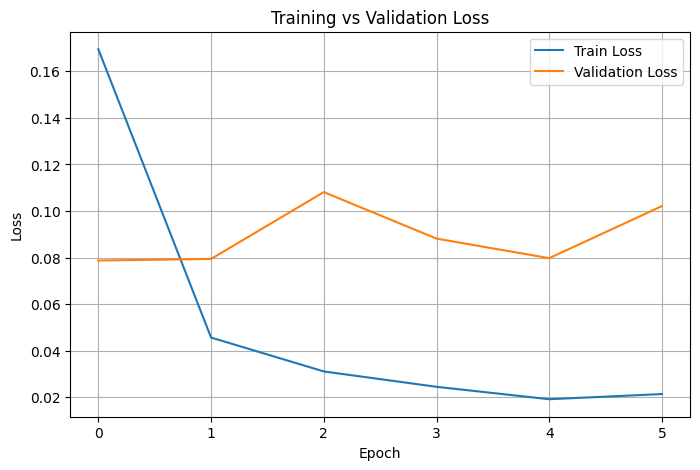

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


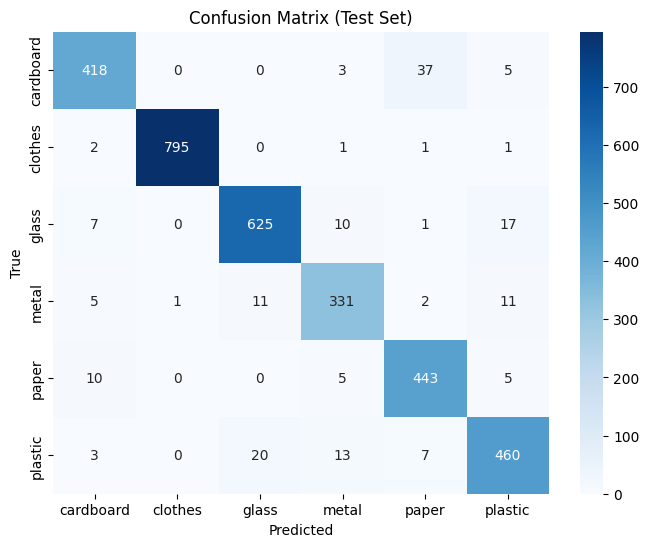


Classification Report (Test Set):

              precision    recall  f1-score   support

   cardboard       0.94      0.90      0.92       463
     clothes       1.00      0.99      1.00       800
       glass       0.95      0.95      0.95       660
       metal       0.91      0.92      0.91       361
       paper       0.90      0.96      0.93       463
     plastic       0.92      0.91      0.92       503

    accuracy                           0.95      3250
   macro avg       0.94      0.94      0.94      3250
weighted avg       0.95      0.95      0.95      3250



In [ ]:
# =========================================================
# DENSENET201 + FOCAL LOSS + ADAMW
# EARLY STOPPING + GÖRSELLER + CONFUSION MATRIX
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1) GOOGLE DRIVE
# ---------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

# ---------------------------------------------------------
# 2) SEED + DEVICE
# ---------------------------------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# 3) TRANSFORMLAR
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# 4) DATASET YOLLARI
# ---------------------------------------------------------
base_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

num_classes = len(train_dataset.classes)
print("Class sayısı:", num_classes)

# ---------------------------------------------------------
# 5) DATALOADER
# ---------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# ---------------------------------------------------------
# 6) FOCAL LOSS
# ---------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=1.0, gamma=2.0)

# ---------------------------------------------------------
# 7) MODEL
# ---------------------------------------------------------
model = models.densenet201(
    weights=models.DenseNet201_Weights.IMAGENET1K_V1
)
model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)
model = model.to(device)

# ---------------------------------------------------------
# 8) OPTIMIZER
# ---------------------------------------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ---------------------------------------------------------
# 9) EARLY STOPPING AYARLARI
# ---------------------------------------------------------
epochs = 20
patience = 5
best_val_loss = float("inf")
counter = 0

model_path = "/content/drive/MyDrive/Derin_Ogrenme/best_densenet201_focal_adamw.pth"

train_losses = []
val_losses = []

# ---------------------------------------------------------
# 10) TRAIN + VALIDATION
# ---------------------------------------------------------
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), model_path)
        print("Best model saved")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")
        if counter >= patience:
            print("Early stopping triggered!")
            break

# ---------------------------------------------------------
# 11) LOSS GRAFİĞİ
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------------
# 12) TEST SET EVALUATION
# ---------------------------------------------------------
model.load_state_dict(torch.load(model_path))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ---------------------------------------------------------
# 13) CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# ---------------------------------------------------------
# 14) CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\nClassification Report (Test Set):\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

# DENSENET201 ADAMW + CROSSENTROPYLOSS

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Class sayısı: 6


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/50] | Train Loss: 0.3508 | Val Loss: 0.1751
  ✔ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/50] | Train Loss: 0.1225 | Val Loss: 0.1723
  ✔ Best model saved


...

Epoch [6/50] | Train Loss: 0.0355 | Val Loss: 0.1857
  ⏳ No improvement (3/5)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [7/50] | Train Loss: 0.0403 | Val Loss: 0.2154
  ⏳ No improvement (4/5)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [8/50] | Train Loss: 0.0394 | Val Loss: 0.1947
  ⏳ No improvement (5/5)
Early stopping triggered!


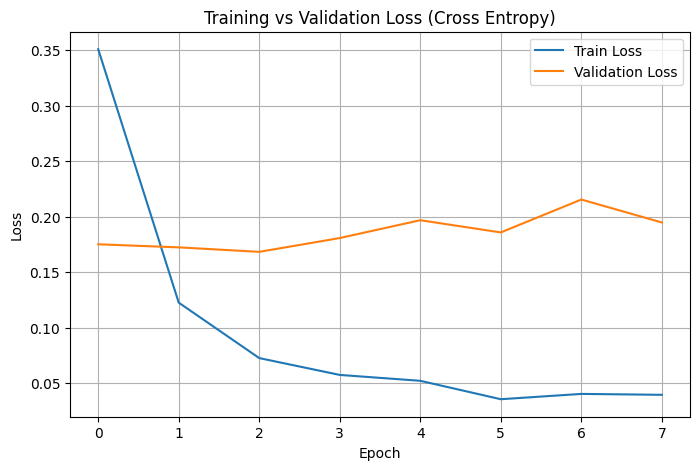

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


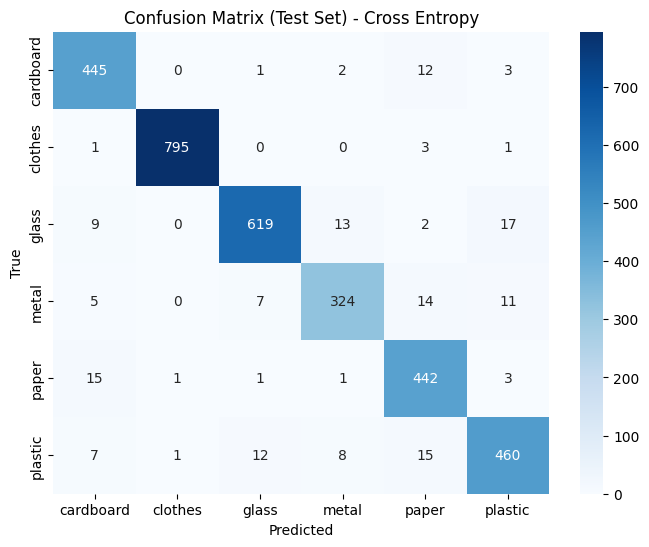


Classification Report (Test Set) - Cross Entropy:

              precision    recall  f1-score   support

   cardboard       0.92      0.96      0.94       463
     clothes       1.00      0.99      1.00       800
       glass       0.97      0.94      0.95       660
       metal       0.93      0.90      0.91       361
       paper       0.91      0.95      0.93       463
     plastic       0.93      0.91      0.92       503

    accuracy                           0.95      3250
   macro avg       0.94      0.94      0.94      3250
weighted avg       0.95      0.95      0.95      3250



In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 2) SEED + DEVICE
# ---------------------------------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# 3) TRANSFORMLAR
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# 4) DATASET YOLLARI
# ---------------------------------------------------------
base_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

num_classes = len(train_dataset.classes)
print("Class sayısı:", num_classes)

# ---------------------------------------------------------
# 5) DATALOADER
# ---------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# ---------------------------------------------------------
# 6) LOSS FUNCTION (CROSS ENTROPY)
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()

# ---------------------------------------------------------
# 7) MODEL (DenseNet201)
# ---------------------------------------------------------
model = models.densenet201(
    weights=models.DenseNet201_Weights.IMAGENET1K_V1
)
model.classifier = nn.Linear(
    model.classifier.in_features,
    num_classes
)
model = model.to(device)

# ---------------------------------------------------------
# 8) OPTIMIZER (AdamW)
# ---------------------------------------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ---------------------------------------------------------
# 9) EARLY STOPPING AYARLARI
# ---------------------------------------------------------
epochs = 50
patience = 5
best_val_loss = float("inf")
counter = 0

model_path = "/content/drive/MyDrive/Derin_Ogrenme/best_densenet201_ce_adamw.pth"

train_losses = []
val_losses = []

# ---------------------------------------------------------
# 10) TRAIN + VALIDATION
# ---------------------------------------------------------
for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), model_path)
        print("Best model saved")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")
        if counter >= patience:
            print("Early stopping triggered!")
            break

# ---------------------------------------------------------
# 11) LOSS GRAFİĞİ
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Cross Entropy)")
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------------
# 12) TEST SET EVALUATION
# ---------------------------------------------------------
model.load_state_dict(torch.load(model_path))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# ---------------------------------------------------------
# 13) CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set) - Cross Entropy")
plt.show()

# ---------------------------------------------------------
# 14) CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\nClassification Report (Test Set) - Cross Entropy:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)

# DENSENET201 ADAM + Focalloss


Using device: cuda
Classes: ['cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic']
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 189MB/s]
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1] | Train: 0.0571 | Val: 0.0131
Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2] | Train: 0.0031 | Val: 0.0064
Best model saved


...

Epoch [5] | Train: 0.0003 | Val: 0.0070


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [6] | Train: 0.0002 | Val: 0.0061


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [7] | Train: 0.0328 | Val: 0.0763
Early stopping


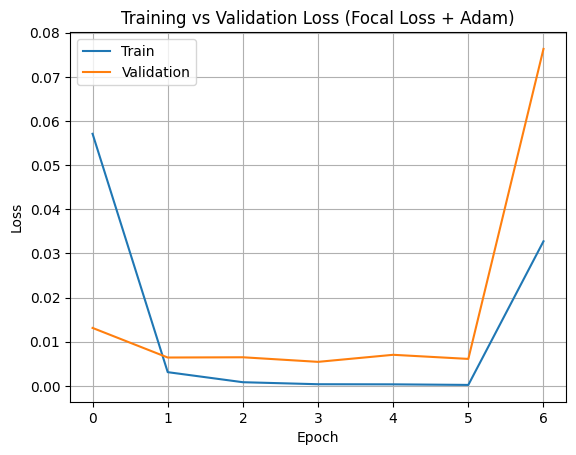

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


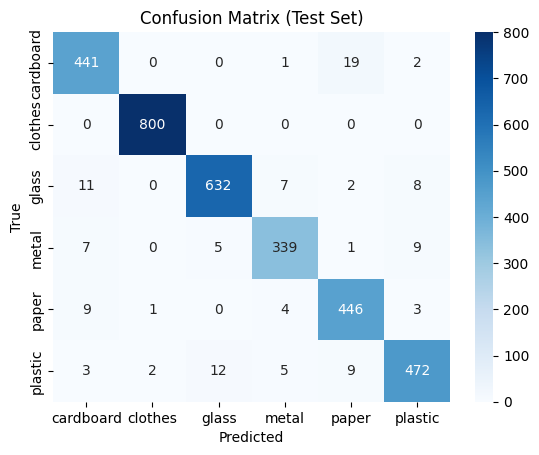


Classification Report:

              precision    recall  f1-score   support

   cardboard       0.94      0.95      0.94       463
     clothes       1.00      1.00      1.00       800
       glass       0.97      0.96      0.97       660
       metal       0.95      0.94      0.95       361
       paper       0.94      0.96      0.95       463
     plastic       0.96      0.94      0.95       503

    accuracy                           0.96      3250
   macro avg       0.96      0.96      0.96      3250
weighted avg       0.96      0.96      0.96      3250



In [ ]:
# =========================================================
# DENSENET201 + ADAM + FOCAL LOSS
# TRAIN / VAL / TEST + EARLY STOPPING
# LOSS GRAFİĞİ + CONFUSION MATRIX + REPORT
# =========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1) SEED + DEVICE
# ---------------------------------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------
# 2) TRANSFORMLAR
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# 3) DATASET YOLU (DOĞRU YOL)
# ---------------------------------------------------------
base_dir = "/content/drive/MyDrive/Derin_Ogrenme/merged_dataset2"

train_dataset = datasets.ImageFolder(f"{base_dir}/train", transform=transform)
val_dataset   = datasets.ImageFolder(f"{base_dir}/val",   transform=transform)
test_dataset  = datasets.ImageFolder(f"{base_dir}/test",  transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ---------------------------------------------------------
# 4) DATALOADER
# ---------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# ---------------------------------------------------------
# 5) FOCAL LOSS
# ---------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0): ## zor örneklere ne kadar ağırlık verecek
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, labels):
        ce_loss = self.ce(logits, labels)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

criterion = FocalLoss(gamma=2.0)

# ---------------------------------------------------------
# 6) MODEL
# ---------------------------------------------------------
model = models.densenet201(
    weights=models.DenseNet201_Weights.IMAGENET1K_V1
)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.to(device)

# ---------------------------------------------------------
# 7) OPTIMIZER
# ---------------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ---------------------------------------------------------
# 8) EARLY STOPPING
# ---------------------------------------------------------
epochs = 10
patience = 3
best_val_loss = float("inf")
counter = 0

model_path = "/content/drive/MyDrive/Derin_Ogrenme/best_densenet201_focal_adam.pth"

train_losses, val_losses = [], []

# ---------------------------------------------------------
# 9) TRAIN + VALIDATION
# ---------------------------------------------------------
for epoch in range(epochs):

    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), model_path)
        print("Best model saved")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# ---------------------------------------------------------
# 10) LOSS GRAFİĞİ
# ---------------------------------------------------------
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Focal Loss + Adam)")
plt.legend()
plt.grid()
plt.show()

# ---------------------------------------------------------
# 11) TEST + CONFUSION MATRIX
# ---------------------------------------------------------
model.load_state_dict(torch.load(model_path))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = torch.argmax(model(x.to(device)), dim=1)
        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))